**Bloque 1: Configuración, Parámetros y Visualización del RAW Data**
En esta primera celda importamos las librerías necesarias, definimos las constantes físicas y del radar, cargamos el archivo binario L0C y visualizamos la matriz original (el caos antes de enfocar).

In [1]:
########################################################################
# FOCALIZADOR RANGE DOPPLER - Palomeque Matias (mpalomeque@conae.gob.ar)
########################################################################
# imports
import numpy as np
from scipy.fft import fft, ifft, fftshift
from scipy.signal import correlate, convolve2d
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import math

########################################################################
# function
def matrix_view(m):
    matrix = np.abs(m)
    min_clip = np.mean(matrix) - 3*np.std(matrix)
    max_clip = np.mean(matrix) + 3*np.std(matrix)
    matrix = np.clip(min_clip, max_clip, matrix)
    plt.imshow(matrix, cmap='gray')
    plt.tight_layout()
    plt.show()

    return matrix

########################################################################

########################################################################

def filter_ml(img, n, m, mode='same'):
    # n filas, m columnas
    kernel = np.ones((n, m)) / (n * m)
    img_f = convolve2d(img, kernel, mode)
    img_f = img_f[::n, ::m]  # Con reducción de imagen
    return img_f
########################################################################


########################################################################
def L0_read(path_bin,lines,samples,lines_v,samples_v,headerOffsetBytes,rowPrefixBytes,samplesPerPixel,bytesPerSample,dtype):

        lin_start, lin_end = lines_v
        samp_start, samp_end = samples_v
        nlines = lin_end - lin_start

        with open(path_bin, 'rb') as f:
            f.seek(headerOffsetBytes, 0)
            f.seek(lin_start * samples * samplesPerPixel * bytesPerSample, 1)

            count = samples * nlines
            data = np.fromfile(f, dtype=dtype, count=count)
            data = data.reshape((nlines, samples))
            data = data[:, samp_start + rowPrefixBytes:samp_end + rowPrefixBytes]

        return data


# parameters

# speed of light
C = 299792458 # m/s
# number of lines
lines = 16974 # Número de pulso que se mandaron. Siempre es mayor que samples
# number of samples
#<Samples>8704</Samples>
samples = 8704 # 
# center frequency // frecuencia de la banda portadora
fc = 1275e6   # Hz
# wavelength
wl = C/fc # m
# sampling frequency
fs = 30e6     # Hz
# chirp pulse length
# <PulseLength unit="s">2.7e-05</PulseLength>
pl = 2.7e-05    # s
# chirp BW
# <Bandwidth unit="Hz">20600000</Bandwidth>
ch_BW = 20600000    # Hz
# sampling window start time
# Tiempo que tarda el pulso entre ir y volver <SamplesStart unit="s">0.005456643268674069708</SamplesStart>
# Me habla del rango cercano
samplesStart = 0.005456643268674069708 # s 
# slant range
sr = C/2*(samplesStart + np.arange(samples)/fs) # m
# pulse repetition frequency
PRF =  1886         # Hz
# doppler BW
dp_BW = 0.8*PRF # Hz
# satellite velocity
'''<vSV_mOs>
        <val N="1">-3385.35580987127</val>
        <val N="2">3083.98735159082</val>
        <val N="3">-6089.99587677747</val>
NOTA: los primeros tres valores me dan la velocidad en los tres ejes, con el módulo obtenog la velocidad absoluta        
'''

vel_abs = math.sqrt((-3385.35580987127*-3385.35580987127)+(3083.98735159082*3083.98735159082)+(-6089.99587677747*-6089.99587677747))
Veff = 7270 #vel_abs       # m/s

## Defino el tipo de dato a leer (Buscar los 4 parámetros en el metadato SAOCOM)

'''<HeaderOffsetBytes>0</HeaderOffsetBytes>
<RowPrefixBytes>0</RowPrefixBytes>
<ByteOrder>LITTLEENDIAN</ByteOrder>
<CellType>FLOAT_COMPLEX</CellType>'''

headerOffsetBytes = 0
rowPrefixBytes = 0
cellType = 'FLOAT_COMPLEX'
byteOrder = 'LITTLEENDIAN'

# Calculo el resto de los árametros necesarios
if cellType == 'FLOAT_COMPLEX':
    samplesPerPixel, bytesPerSample = 2, 4

if byteOrder == 'LITTLEENDIAN': endianness = '<'
elif byteOrder == 'BIGENDIAN': endianness = '>'
else: raise ValueError("ByteOrder inválido")

code = bytesPerSample + samplesPerPixel
dtype_map = {
    2: np.uint8,
    5: np.float32,
    6: np.complex64,
    9: np.float64,
    10: np.complex128
}
dtype = np.dtype(dtype_map.get(code)).newbyteorder(endianness)


########################################################################
# load L0C Stripmap HH Sosneado
print('load SAOCOM L0C(RAW) Stripmap HH Sosneado')

path_bin = 'L0C_Stripmap_HH_SOSNEADO/l0-acqId0000513531-b-sm6-0000000000-s6dp-hh'
lines_v = [0,lines]
samples_v = [0,samples]

L0C = L0_read(path_bin,lines,samples,lines_v,samples_v,headerOffsetBytes,rowPrefixBytes,samplesPerPixel,bytesPerSample,dtype)
L0C = L0C.reshape(lines, samples)
print('L0C.shape', L0C.shape)

'''raw = matrix_view(L0C)
# Reducimos tamaño mediante multilook
raw_ml = filter_ml(raw, 5, 5)
# Exportamos el dato crudo con el mapa de colores en grises
plt.imsave('RAW.png', raw_ml, cmap='gray')
'''

load SAOCOM L0C(RAW) Stripmap HH Sosneado
L0C.shape (16974, 8704)


"raw = matrix_view(L0C)\n# Reducimos tamaño mediante multilook\nraw_ml = filter_ml(raw, 5, 5)\n# Exportamos el dato crudo con el mapa de colores en grises\nplt.imsave('RAW.png', raw_ml, cmap='gray')\n"

**Bloque 2: Compresión en Rango**
Esta celda aplica el filtro adaptado utilizando el chirp en el dominio del tiempo para colapsar la energía transversal al vuelo.

In [2]:
########################################################################
# range compression (time-domain)
print('range compression (time-domain)')

m = L0C

t_sr = pl/int(pl*fs)*np.arange(int(pl*fs))
t_sr = t_sr - np.mean(t_sr)
K = -ch_BW/pl # chirp rate
chirp = np.exp(1j*np.pi*K*t_sr**2) # chirp

for i in range(lines):
    m[i, :] = correlate(m[i, :], chirp, mode='same', method='fft')


'''rc = matrix_view(m)
# Reducimos tamaño mediante multilook
rc_ml = filter_ml(rc, 5, 5)
# Exportamos el dato comprimido en Rango con el mapa de colores en grises
plt.imsave('RC.png', rc_ml, cmap='gray')'''

range compression (time-domain)


"rc = matrix_view(m)\n# Reducimos tamaño mediante multilook\nrc_ml = filter_ml(rc, 5, 5)\n# Exportamos el dato comprimido en Rango con el mapa de colores en grises\nplt.imsave('RC.png', rc_ml, cmap='gray')"

**Bloque 3: Range Migration (RCMC)**
Acá procesamos la compensación de migración de celdas en rango (RCMC) pasando al dominio Range-Doppler. Esta celda se encarga de "enderezar" las curvas geométricas generadas por el movimiento del sensor. En el caso de imágenes SAR satelitales, el efecto es menos evidente que en SAR aerotransportado.

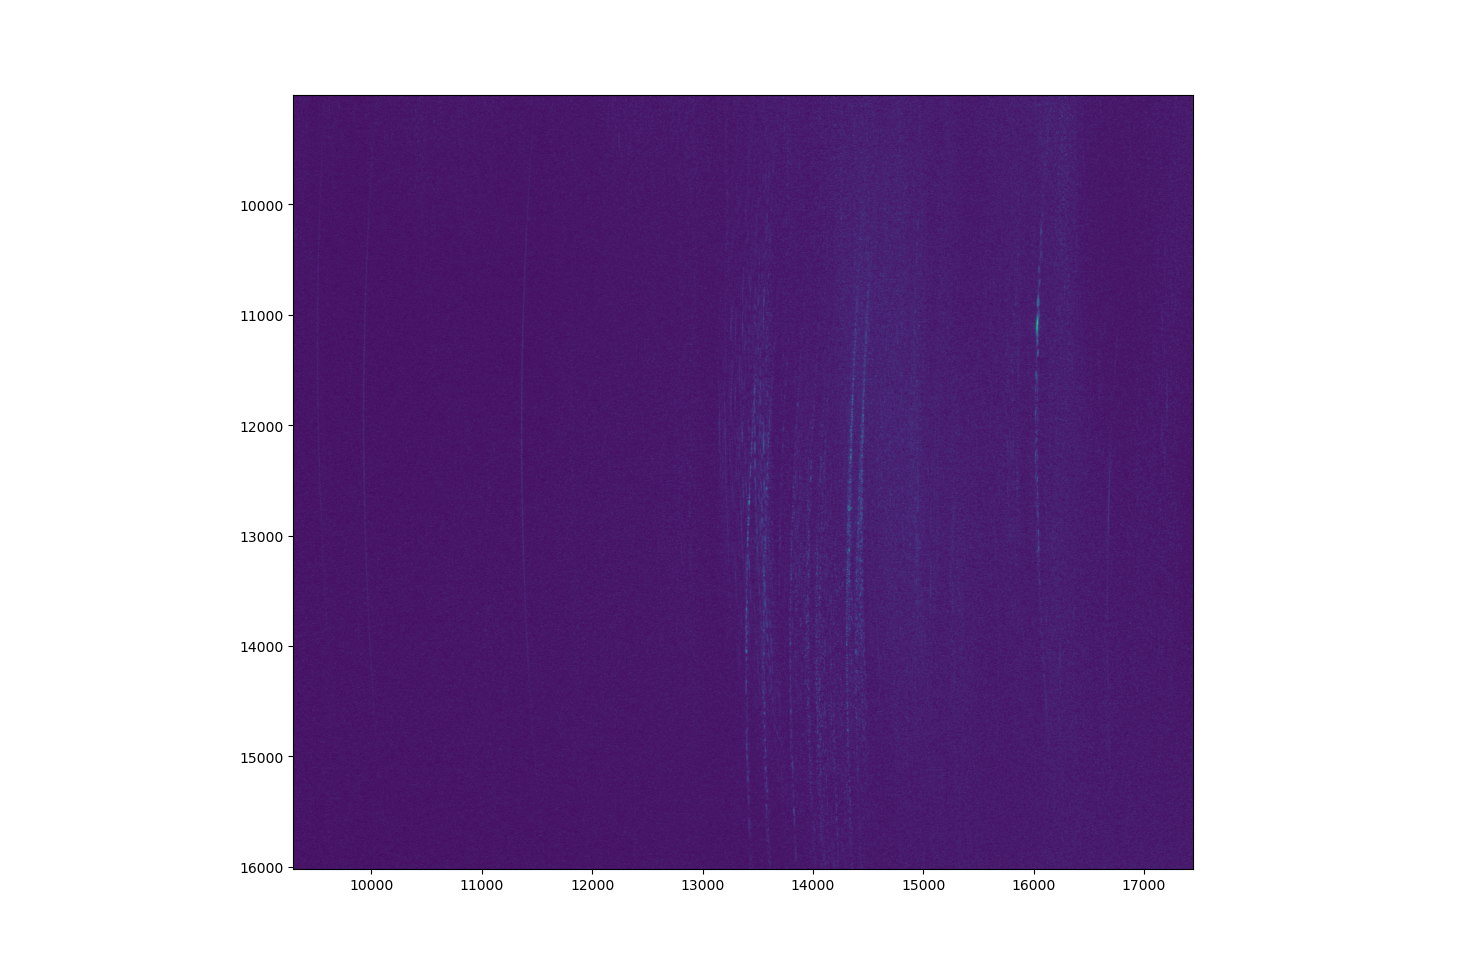

In [3]:
########################################################################
# range cell migration correction (range_doppler-domain)
print('range cell migration correction (range_doppler-domain)')

m = fftshift(fft(m, axis=0), axes=0)
freq_az = PRF/lines*np.arange(lines)
freq_az = freq_az - np.mean(freq_az)

alpha_rcmc = (wl**2)/(8*Veff**2)
for i in range(lines):
    rcmc = sr*(1 + alpha_rcmc*freq_az[i]**2)
    rcmc = np.clip(rcmc, np.min(sr), np.max(sr))

    aux_real = m[i, :].real
    cs_real = CubicSpline(sr, aux_real)
    aux_real = cs_real(rcmc).astype(np.float32)

    aux_imag = m[i, :].imag
    cs_imag = CubicSpline(sr, aux_imag)
    aux_imag = cs_imag(rcmc).astype(np.float32)

    aux = aux_real + 1j*aux_imag
    aux = aux.astype(np.complex64)
    m[i, :] = aux

m = ifft(fftshift(m, axes=0), axis=0)

'''cm = matrix_view(m)
# Reducimos tamaño mediante multilook
cm_ml = filter_ml(cm, 5, 5)
# Exportamos el dato corregido por cell Migration con el mapa de colores en grises
plt.imsave('CM.png', cm_ml, cmap='gray')'''

range cell migration correction (range_doppler-domain)


"cm = matrix_view(m)\n# Reducimos tamaño mediante multilook\ncm_ml = filter_ml(cm, 5, 5)\n# Exportamos el dato corregido por cell Migration con el mapa de colores en grises\nplt.imsave('CM.png', cm_ml, cmap='gray')"

**Bloque 4: Compresión en Azimuth y Guardado del dato SLC**
Finalmente, este bloque sintetiza la apertura comprimiendo la historia de fase a lo largo de la trayectoria de vuelo y luego guarda el resultado en un archivo binario final (Single Look Complex).

azimuth compression (time-domain)


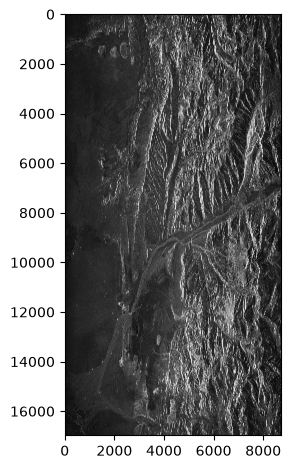

save SLC
SLC type: np.complex64
SLC.shape (16974, 8704)
Procesamiento completado y archivo SLC guardado con éxito.


In [4]:
########################################################################
# azimuth compression (time-domain)
print('azimuth compression (time-domain)')

for i in range(samples):
    K = -2*Veff**2/wl/sr[i] # chirp rate
    ll = np.abs(dp_BW/K) # chirp length/duration
    t_az = ll/int(ll*PRF)*np.arange(int(ll*PRF))
    t_az = t_az - np.mean(t_az)
    chirp = np.exp(1j*np.pi*K*t_az**2)

    m[:, i] = correlate(m[:, i], chirp, mode='same', method='fft')

slc = matrix_view(m)
# Reducimos tamaño mediante multilook
slc_ml = filter_ml(slc, 5, 5)
# Exportamos el dato comprimido en Rango con el mapa de colores en grises
plt.imsave('SLC.png', slc_ml, cmap='gray')

########################################################################
# save SLC
print('save SLC')

SLC = m
print('SLC type: np.complex64')
print('SLC.shape', SLC.shape)
SLC.tofile('SLC.bin')
print('Procesamiento completado y archivo SLC guardado con éxito.')

**Fin del algoritmo de compresión Range Doppler**